In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Đọc ảnh


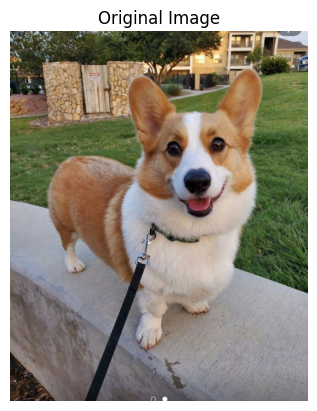

In [3]:
image = cv2.imread('anh.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image[:, :, ::-1] # Tạo một bản sao của ảnh gốc để tránh thay đổi ảnh gốc
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')  
plt.show()

1. Thay đổi độ sáng

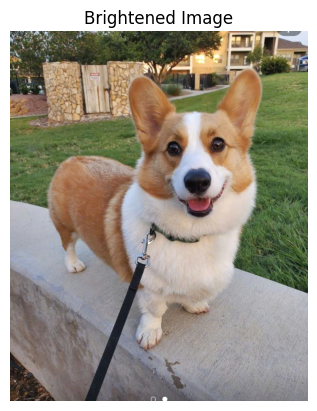

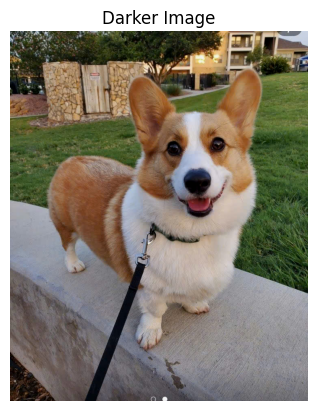

In [4]:
# bright = cv2.convertScaleAbs(image, alpha=0.5, beta=50)

bright = np.clip(image.astype(np.float16) +10,0,255).astype(np.uint8)
dart = np.clip(image.astype(np.float16) -10,0,255).astype(np.uint8)

plt.imshow(bright)

plt.title('Brightened Image')
plt.axis('off')
plt.show()

plt.imshow(dart)
plt.title('Darker Image')
plt.axis('off')
plt.show()

2. thay đổi độ tương phản

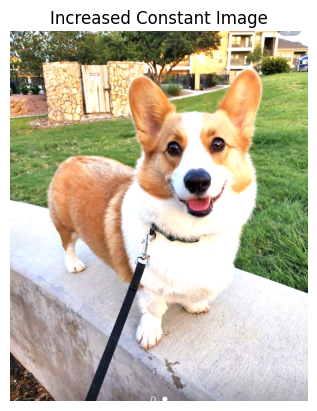

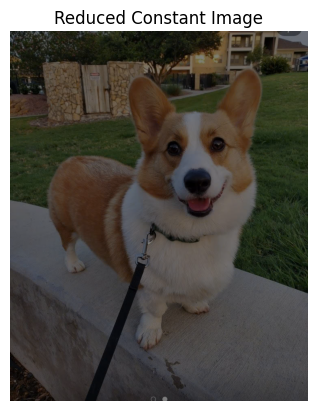

In [5]:


# constant = cv2.convertScaleAbs(image, alpha=1.5, beta=0)
increased_constant = np.clip(image.astype(np.float32) * 1.5, 0, 255).astype(np.uint8)
reduce_constant = np.clip(image.astype(np.float32) * 0.5, 0, 255).astype(np.uint8)
plt.imshow(increased_constant)
plt.title('Increased Constant Image')
plt.axis('off')
plt.show()
plt.imshow(reduce_constant)
plt.title('Reduced Constant Image')
plt.axis('off')
plt.show()

3. Biến đổi âm bản

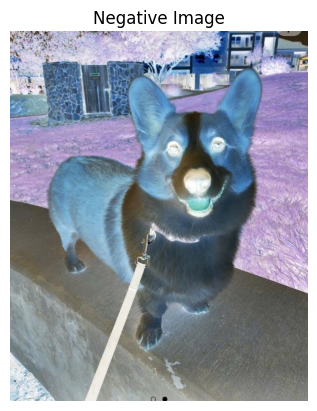

In [6]:

negative = cv2.convertScaleAbs(image, alpha=-1, beta=255)
# negative = 225 -image
# negative = np.clip(255 - image.astype(np.float32), 0, 255).astype(np.uint8)
plt.imshow(negative)
plt.title('Negative Image')
plt.axis('off')
plt.show()

4. cắt ngưỡng

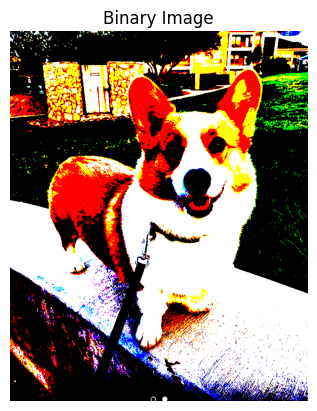

In [7]:
_,binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
# binary = np.where(image > 128, 255, 0).astype(np.uint8)
plt.imshow(binary)
plt.title('Binary Image')
plt.axis('off')
plt.show()

II> Lọc Tuyến Tính
1. Lọc trung bình của

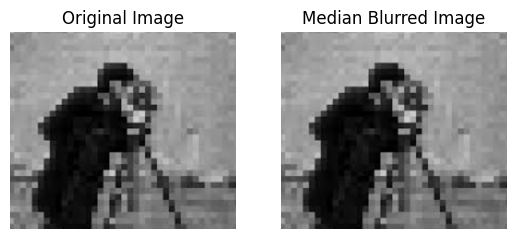

In [ ]:



def medianblur_filter(image, kernel_size=3):
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be an odd integer.")

    return cv2.medianBlur(image, kernel_size)


# Example usage
img = cv2.imread('anh1.jpg')
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
filtered_image = medianblur_filter(image, kernel_size=3)
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image)
plt.title('Median Blurred Image')
plt.axis('off')
plt.show()

II> Lọc Tuyến Tính
2. 2> Lọc Gaussian 

In [51]:

def gaussian_filter(img, kernel_size=5):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)



# Áp dụng lọc Gaussian
filtered_img = gaussian_filter(img, 5)

# Hiển thị ảnh
cv2.imshow('Original', img)
cv2.imshow('Filtered', filtered_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

II> Lọc Tuyến Tính
2. 2> Làm sắc nét 

(914, 735, 3)


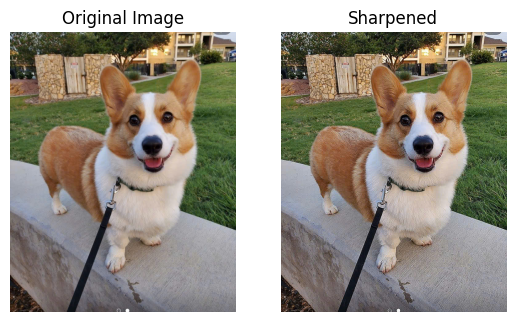

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh thật
img = cv2.imread('anh.jpg')

# kiểm tra có đọc được không
print(img.shape)  # nếu lỗi là None thì ảnh không tồn tại

# chuyển BGR -> RGB để hiển thị đúng màu
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# kernel sharpen
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

# áp dụng filter
output_cv = cv2.filter2D(image, -1, kernel)

# hiển thị
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_cv)
plt.title('Sharpened')
plt.axis('off')

plt.show()

III> Bài nâng cao
1.Phát hiện cạnh: Sử dụng các kernel Sobel, Prewitt để phát hiện các cạnh trong ảnh. 

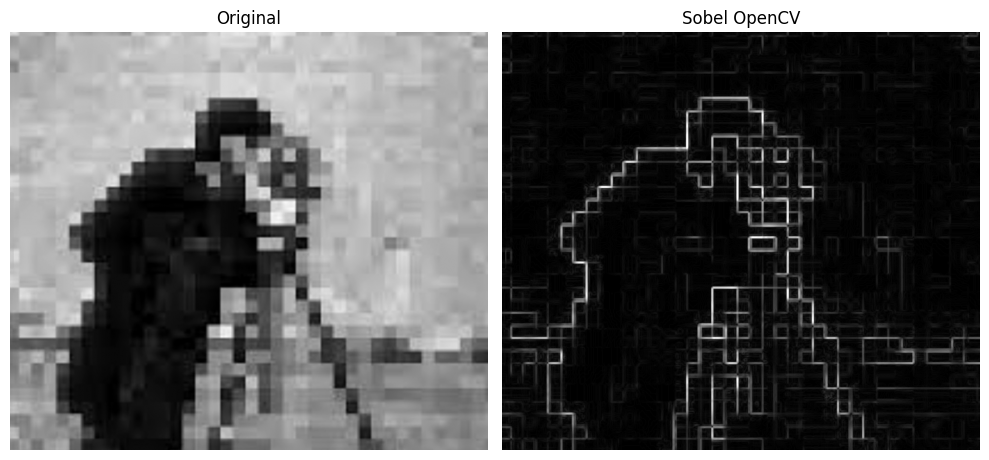

In [ ]:
image = cv2.imread('anh1.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Tính đạo hàm theo trục X
gx_cv = cv2.filter2D(gray, cv2.CV_32F, sobel_x)
#Tính đạo hàm
gy_cv = cv2.filter2D(gray, cv2.CV_32F, sobel_y)
#Ghép 2 hướng lại
sobel_cv = np.sqrt(gx_cv**2 + gy_cv**2)
#Chuẩn hóa ảnh về 0–255
sobel_cv = np.uint8(np.clip(sobel_cv, 0, 255))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sobel_cv, cmap='gray')
plt.title("Sobel OpenCV")
plt.axis('off')

plt.tight_layout()
plt.show()

2. Tự thiết kế kernel: Tạo các kernel tùy chỉnh để đạt được các hiệu ứng khác nhau.


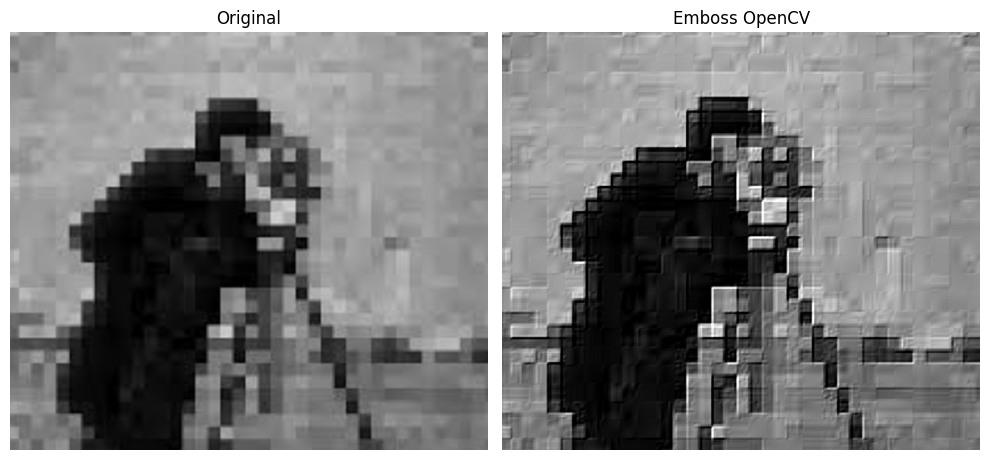

In [36]:
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
], dtype=np.float32)

output_cv = cv2.filter2D(
    image,
    -1,
    kernel_emboss
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_cv)
plt.title("Emboss OpenCV")
plt.axis('off')

plt.tight_layout()
plt.show()

3. So sánh các loại lọc: So sánh hiệu quả của các loại lọc khác nhau trên cùng một hình ảnh. (numpy)


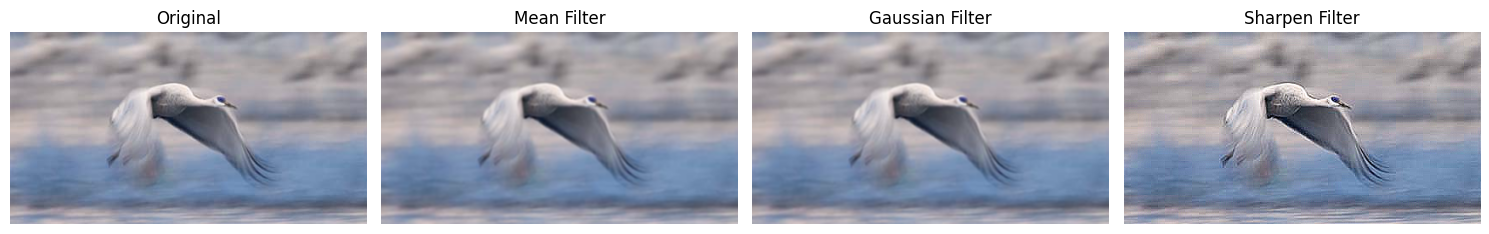

In [49]:
image = cv2.imread('anh3.jpg')

mean_cv = cv2.blur(image, (3,3))
gaussian_cv = cv2.GaussianBlur(image, (3,3), 1)

kernel_sharpen = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
], dtype=np.float32)

sharpen_cv = cv2.filter2D(
    image,
    -1,
    kernel_sharpen
)

# Hiển thị
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mean_cv)
plt.title('Mean Filter')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gaussian_cv)
plt.title('Gaussian Filter')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(sharpen_cv)
plt.title('Sharpen Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

4 Áp dụng lọc phi tuyến tính: Tìm hiểu về các loại lọc không tuyến tính như median filter, bilateral filter. 

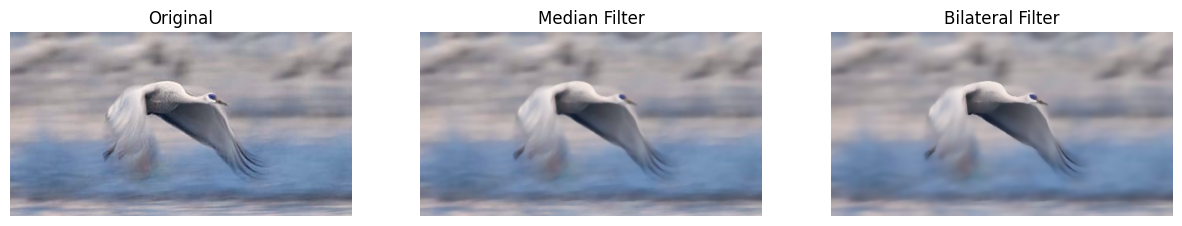

In [50]:
image = cv2.imread('anh3.jpg')
median = cv2.medianBlur(image, 5)  


bilateral = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(median)
plt.title("Median Filter")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(bilateral)
plt.title("Bilateral Filter")
plt.axis('off')

plt.show()
